# Project work, part 1 - Dashboard basics
This notebook explores reservoir data and provides the analytical foundation for the accompanying Streamlit application.

## GitHub Repository and Streamlit App

https://github.com/sgkop/IND320-Innlevering-sgkop

https://ind320-innlevering1-sgkop.streamlit.app/

## Load and Explore Dataset

In [1]:
# Import pandas and load the reservoir dataset

import pandas as pd

df = pd.read_csv("../data/reservoirs.csv")

display(df.head())

print(df.columns)

df.info()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsg

## Rename Columns

In [2]:
# Rename Norwegian column names to English

df = df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "year",
    "iso_uke": "week",
    "fyllingsgrad": "filling_ratio",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_energy_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_ratio",
    "endring_fyllingsgrad": "filling_ratio_change"
})

display(df.head())

print(df.columns)

,date,area_type,area_number,year,week,filling_ratio,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_filling_ratio,filling_ratio_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


Index(['date', 'area_type', 'area_number', 'year', 'week', 'filling_ratio',
       'capacity_TWh', 'stored_energy_TWh', 'next_publication_date',
       'previous_week_filling_ratio', 'filling_ratio_change'],
      dtype='str')


## Summary Statistics

In [3]:
# Display summary information about the dataset

df.info()

display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         14877 non-null  str    
 1   area_type                    14877 non-null  str    
 2   area_number                  14877 non-null  int64  
 3   year                         14877 non-null  int64  
 4   week                         14877 non-null  int64  
 5   filling_ratio                14877 non-null  float64
 6   capacity_TWh                 14877 non-null  float64
 7   stored_energy_TWh            14877 non-null  float64
 8   next_publication_date        14877 non-null  str    
 9   previous_week_filling_ratio  14877 non-null  float64
 10  filling_ratio_change         14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


,area_number,year,week,filling_ratio,capacity_TWh,stored_energy_TWh,previous_week_filling_ratio,filling_ratio_change
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
std,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623


## Data Preparation

In [4]:
# Convert date column and sort by date

import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(by="date")

## Plot Each Column Separately

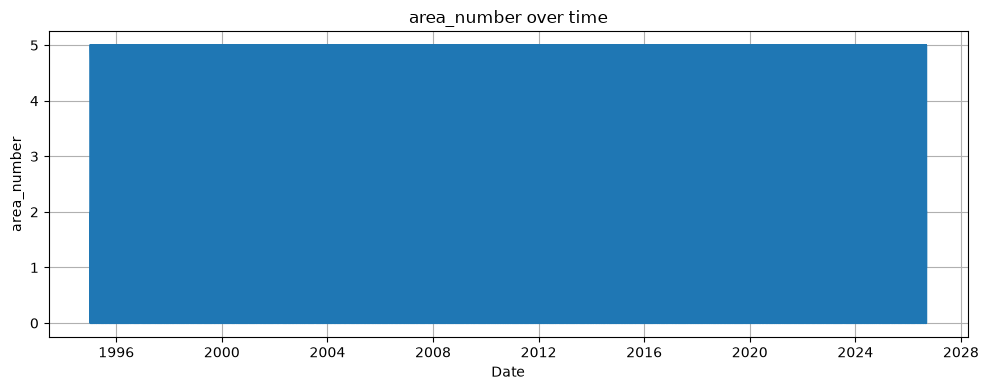

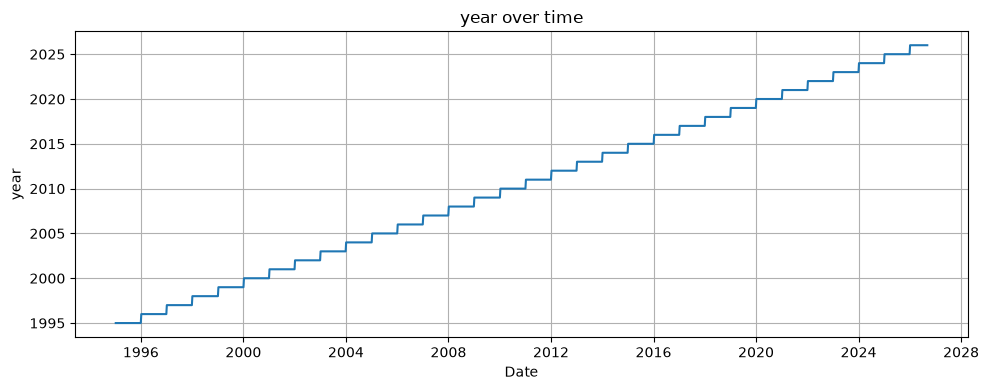

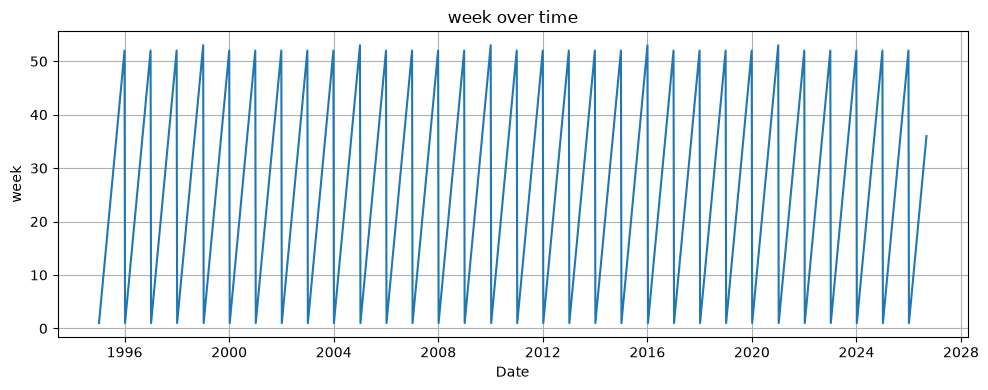

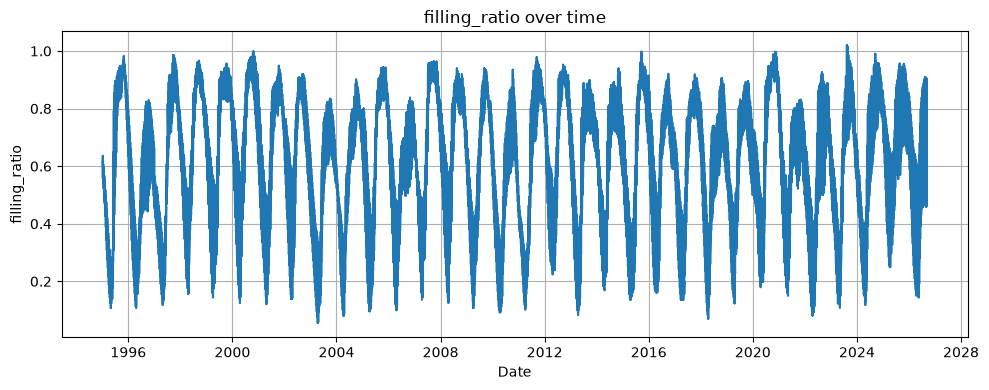

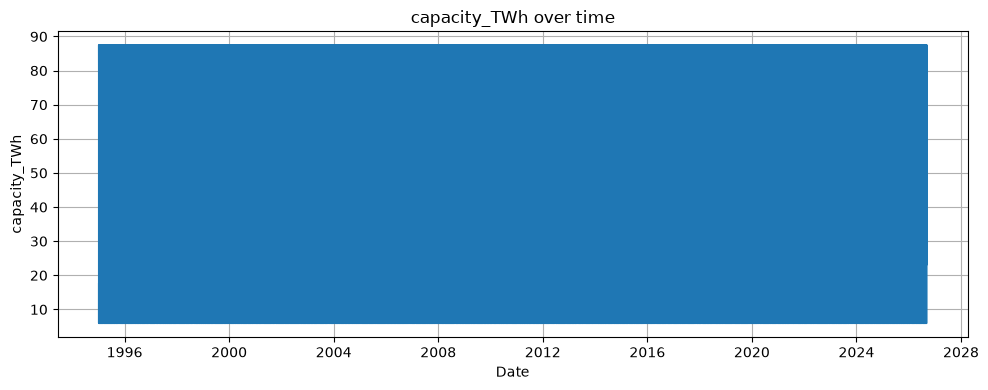

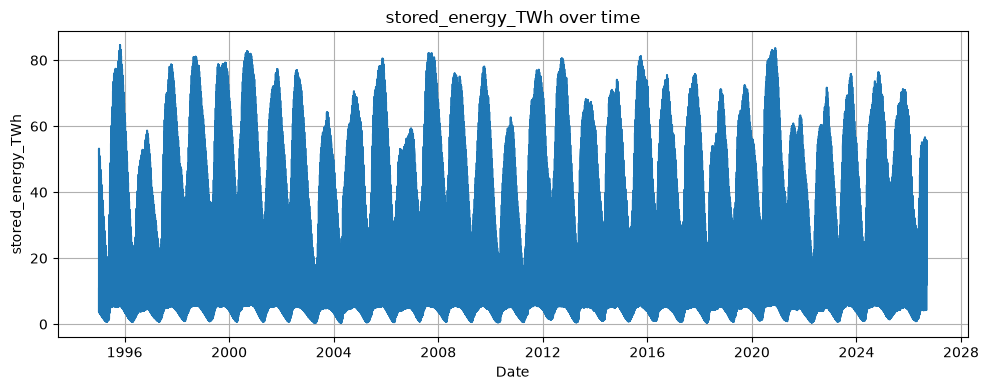

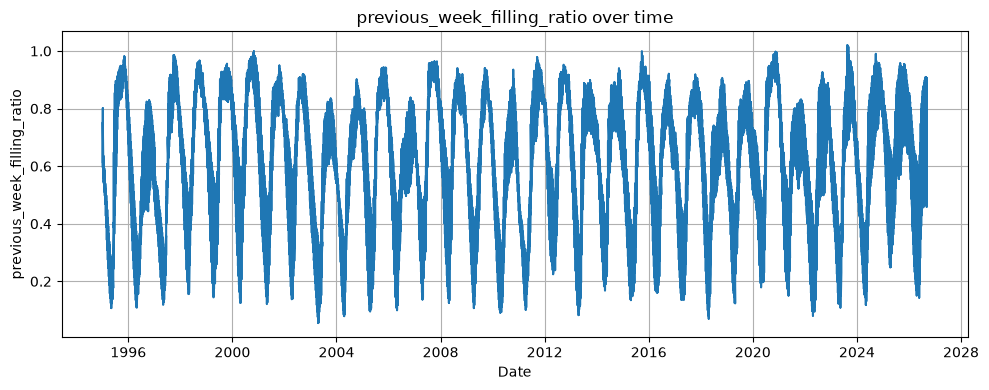

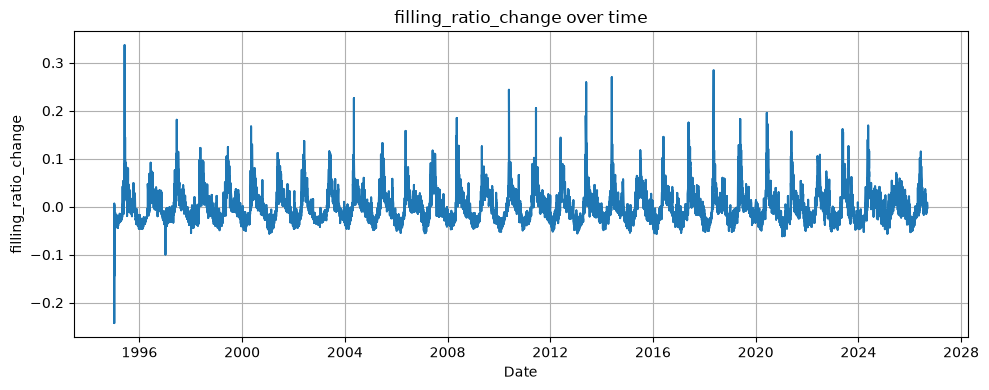

In [5]:
# Numerical columns used for plotting
numeric_columns = [
    "area_number",
    "year",
    "week",
    "filling_ratio",
    "capacity_TWh",
    "stored_energy_TWh",
    "previous_week_filling_ratio",
    "filling_ratio_change"
]

# Create individual plots
for col in numeric_columns:
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(df["date"], df[col])
    
    plt.title(f"{col} over time")
    plt.xlabel("Date")
    plt.ylabel(col)
    
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()

## Plot All Columns Together

The variables use different units and scales. In addition, the dataset contains multiple reservoir areas for each date. To create a meaningful comparison, values are aggregated by date and normalized before plotting.

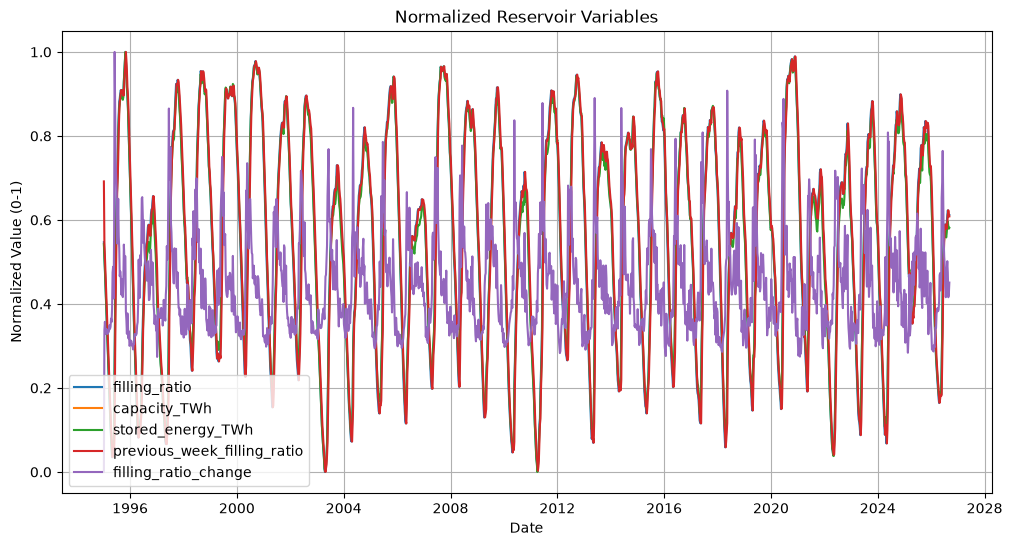

In [6]:
# Variables included in the combined plot

plot_columns = [
    "filling_ratio",
    "capacity_TWh",
    "stored_energy_TWh",
    "previous_week_filling_ratio",
    "filling_ratio_change"
]

# Aggregate values by date

df_plot = (
    df.groupby("date")[plot_columns]
      .mean()
      .reset_index()
)

# Normalize values to range 0-1

df_normalized = df_plot.copy()

for col in plot_columns:
    df_normalized[col] = (
        df_plot[col] - df_plot[col].min()
    ) / (
        df_plot[col].max() - df_plot[col].min()
    )

# Create combined plot

plt.figure(figsize=(12, 6))

for col in plot_columns:

    plt.plot(
        df_normalized["date"],
        df_normalized[col],
        label=col
    )

plt.title("Normalized Reservoir Variables")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0-1)")
plt.legend()
plt.grid(True)

plt.show()

## Project Log

This project was my first experience using Visual Studio Code and Streamlit. A significant amount of time was spent learning package installation, virtual environments, debugging and project organization. Although this increased the workload, it also provided valuable experience with tools that will likely be useful in future projects.

### Project Structure

Part of the work involved deciding how to organize the project files. Since the later compulsory assignments are expected to build on earlier work, I wanted a structure that could be reused later. The dataset was placed in a separate `data` folder, while the notebook and Streamlit application were kept separate. I spent time learning how relative file paths work because the notebook, dataset and application were located in different folders.

### Jupyter Notebook

The notebook was used to explore the dataset and develop the visualizations later used in the Streamlit application. The first steps were importing the CSV file, examining the dataset using functions such as `head()`, `info()` and `describe()`, and renaming the Norwegian column names to English names.

One challenge was that the notebook gradually became difficult to navigate as more tests, plots and code cells were added. Looking back, I would have benefited from organizing the notebook into clearer sections earlier in the project.

### Plotting Challenges

The most time-consuming part of the project involved plotting the data.

Plotting individual columns was technically simple, but several graphs were difficult to interpret. Variables such as `area_number`, `year` and `week` produced visualizations that contained little useful information because they mainly function as identifiers or calendar information rather than measurements.

The largest challenge was the requirement to plot all columns together while considering different scales. Some variables were measured in TWh, while others were ratios. When plotted directly in the same graph, the TWh variables dominated the visualization and made other variables difficult to see.

A second challenge was discovering that the dataset contains observations from multiple reservoir areas for the same date. When all observations were plotted directly, the graphs became cluttered with overlapping lines. Several alternative solutions were considered, including filtering, separating variables into groups and using aggregated values. The final solution used aggregated values by date together with normalization when displaying all variables in the same graph.

These decisions also affected the appearance of the Streamlit application. The same issues that appeared in the notebook became visible in the dashboard until the visualizations were redesigned.

### Streamlit Experience

The Streamlit application was built using the work completed in the notebook. The application includes multiple pages, navigation, interactive plots, caching and a data table with LineChartColumn visualizations. The issues discovered during plotting in the notebook also affected the Streamlit application. The final visualization choices in the dashboard were therefore based on the lessons learned during the notebook analysis.



## AI Usage

I acknowledge the use of M365 Copilot (https://www.microsoft.com/copilot), based on the GPT‑5 chat model, during this project.

M365 Copilot was used to discuss project structure, assist with debugging, explain data visualization choices, and support the development of the Streamlit application. It was also used to review and improve written documentation.

All code, visualizations and written content were reviewed, tested and adapted to reflect my own understanding and decisions.